In [51]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score,precision_score,confusion_matrix, roc_auc_score,plot_roc_curve

In [2]:
pd.set_option ( 'display.max_columns', None)

In [3]:
customers = pd.read_csv('orders.csv')
customers.head()

C:\Users\pavan\Anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3165: DtypeWarning: Columns (1,25,26,27,28,29,30,31,32,33,38,43,45,46,50,56,58,60,69) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,


,Name,Email,Financial Status,Paid at,Fulfillment Status,Fulfilled at,Accepts Marketing,Currency,Subtotal,Shipping,Taxes,Total,Discount Code,Discount Amount,Shipping Method,Created at,Lineitem quantity,Lineitem name,Lineitem price,Lineitem compare at price,Lineitem sku,Lineitem requires shipping,Lineitem taxable,Lineitem fulfillment status,Billing Name,Billing Street,Billing Address1,Billing Address2,Billing Company,Billing City,Billing Zip,Billing Province,Billing Country,Billing Phone,Shipping Name,Shipping Street,Shipping Address1,Shipping Address2,Shipping Company,Shipping City,Shipping Zip,Shipping Province,Shipping Country,Shipping Phone,Notes,Note Attributes,Cancelled at,Payment Method,Payment Reference,Refunded Amount,Vendor,Id,Tags,Risk Level,Source,Lineitem discount,Tax 1 Name,Tax 1 Value,Tax 2 Name,Tax 2 Value,Tax 3 Name,Tax 3 Value,Tax 4 Name,Tax 4 Value,Tax 5 Name,Tax 5 Value,Phone,Receipt Number,Duties,Billing Province Name,Shipping Province Name,Payment ID,Payment Terms Name,Next Payment Due At
0,#8472,sorrownot@aol.com,paid,2022-04-11 19:51:08 -0400,unfulfilled,NaN,no,USD,58.0,4.68,0.0,62.68,NaN,0.0,First Class Package,2022-04-11 19:51:07 -0400,1,Vineyard - Rose DK,29.0,NaN,NaN,True,True,pending,patricia dicostanzo,205 E Rocks Rd,205 E Rocks Rd,NaN,NaN,Norwalk,'06851,CT,US,+12036675831,patricia dicostanzo,205 E Rocks Rd,205 E Rocks Rd,NaN,NaN,Norwalk,'06851,CT,US,+12036675831,NaN,created_at: 1649698296\nmc_cid: 85a03abb50,NaN,Shopify Payments,c26969780125893.1,0.0,Ruby and Roses Yarn,4.322999e+12,NaN,Low,web,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Connecticut,Connecticut,NaN,NaN,NaN
1,#8472,sorrownot@aol.com,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-04-11 19:51:07 -0400,1,Persian - Rose DK,29.0,NaN,NaN,True,True,pending,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Ruby and Roses Yarn,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,#8471,eva.bjernelind@gmail.com,paid,2022-04-11 16:23:13 -0400,unfulfilled,NaN,yes,USD,234.0,55.48,0.0,289.48,NaN,0.0,First Class Package International,2022-04-11 16:23:13 -0400,1,Christmas Advent Calendar ~ 2022 - twenty four...,234.0,NaN,NaN,True,True,pending,Eva Bjernelind,Aada Gaard Lugnet,Aada Gaard Lugnet,NaN,NaN,Trosa,619 91,NaN,SE,NaN,Eva Bjernelind,Aada Gaard Lugnet,Aada Gaard Lugnet,NaN,NaN,Trosa,619 91,NaN,SE,NaN,NaN,NaN,NaN,PayPal Express Checkout,p1039014854853.1,0.0,Ruby and Roses Yarn,4.322819e+12,NaN,Low,web,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.673439e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,#8470,tiffanyakelley@gmail.com,paid,2022-04-11 15:56:58 -0400,unfulfilled,NaN,yes,USD,234.0,12.54,0.0,246.54,NaN,0.0,Parcel Select Ground,2022-04-11 15:56:57 -0400,1,Christmas Advent Calendar ~ 2022 - twenty four...,234.0,NaN,NaN,True,True,pending,Tiffany Kelley,435 Canyon Dr,435 Canyon Dr,NaN,NaN,Grants pass,'97527,OR,US,+15417875723,Tiffany Kelley,435 Canyon Dr,435 Canyon Dr,NaN,NaN,Grants pass,'97527,OR,US,+15417875723,NaN,NaN,NaN,Shopify Payments,p1039012266181.1,0.0,Ruby and Roses Yarn,4.322788e+12,NaN,Low,web,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Oregon,Oregon,NaN,NaN,NaN
4,#8469,sherrykhenderson@gmail.com,paid,2022-04-11 14:26:31 -0400,unfulfilled,NaN,yes,USD,234.0,8.65,0.0,242.65,NaN,0.0,Parcel Select Ground,2022-04-11 14:26:30 -0400,1,Christmas Advent Calendar ~ 2022 - twenty four...,234.0,NaN,NaN,True,True,pending,Sherry Henderson,13107 Worthington St,13107 Worthington St,NaN,NaN,Sugar Land,'77478,TX,US,NaN,Sherry Henderson,13107 Worthington St,13107 Worthington St,NaN,NaN,Sugar Land,'77478,TX,US,NaN,NaN,created_at: 1649697441\nmc_cid: 85a03abb50,NaN,PayPal Express Checkout,c26967401300165.1,0.0,Ruby and Roses Yarn,4.322684e+12,NaN,Low,web,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Texas,Texas,NaN,NaN,NaN


In [4]:
customers.Source.value_counts()

web                    5756
580111                  181
shopify_draft_order     108
3890849                   1
iphone                    1
Name: Source, dtype: int64

In [5]:
features = [ 'Financial Status', 
        'Accepts Marketing', 'Currency', 'Subtotal', 'Shipping',
       'Taxes', 'Total',  'Discount Amount', 'Shipping Method',
    'Lineitem quantity', 'Lineitem name', 'Lineitem price',
       'Lineitem compare at price', 'Lineitem sku',
       'Lineitem requires shipping', 'Lineitem taxable',
       'Lineitem fulfillment status', 
 'Shipping Province',
       'Shipping Country', 
       'Cancelled at', 'Payment Method', 
       'Refunded Amount',  'Risk Level', 'Source',
       'Lineitem discount']

In [6]:
print(len(customers))
#customers.dropna(inplace=True)
print(len(customers))

12104
12104


In [7]:
y= customers['Fulfillment Status']

In [8]:
X=customers[features]

In [9]:
X.isna().sum()

Financial Status                6057
Accepts Marketing               6057
Currency                        6057
Subtotal                        6057
Shipping                        6057
Taxes                           6057
Total                           6057
Discount Amount                 6057
Shipping Method                 6343
Lineitem quantity                  0
Lineitem name                      0
Lineitem price                     0
Lineitem compare at price      12102
Lineitem sku                   12064
Lineitem requires shipping         0
Lineitem taxable                   0
Lineitem fulfillment status        0
Shipping Province               6235
Shipping Country                6146
Cancelled at                   12091
Payment Method                  6057
Refunded Amount                 6057
Risk Level                      6057
Source                          6057
Lineitem discount                  0
dtype: int64

In [10]:
X.dtypes

Financial Status                object
Accepts Marketing               object
Currency                        object
Subtotal                       float64
Shipping                       float64
Taxes                          float64
Total                          float64
Discount Amount                float64
Shipping Method                 object
Lineitem quantity                int64
Lineitem name                   object
Lineitem price                 float64
Lineitem compare at price      float64
Lineitem sku                   float64
Lineitem requires shipping        bool
Lineitem taxable                  bool
Lineitem fulfillment status     object
Shipping Province               object
Shipping Country                object
Cancelled at                    object
Payment Method                  object
Refunded Amount                float64
Risk Level                      object
Source                          object
Lineitem discount              float64
dtype: object

In [11]:
len(X),len(y)

(12104, 12104)

In [12]:
cat_col = []
num_col = []
for i in X.columns:
    if X[i].dtype=='O':
        cat_col.append(i)
    else:
        num_col.append(i)
print(cat_col)
print(num_col)

['Financial Status', 'Accepts Marketing', 'Currency', 'Shipping Method', 'Lineitem name', 'Lineitem fulfillment status', 'Shipping Province', 'Shipping Country', 'Cancelled at', 'Payment Method', 'Risk Level', 'Source']
['Subtotal', 'Shipping', 'Taxes', 'Total', 'Discount Amount', 'Lineitem quantity', 'Lineitem price', 'Lineitem compare at price', 'Lineitem sku', 'Lineitem requires shipping', 'Lineitem taxable', 'Refunded Amount', 'Lineitem discount']


In [13]:
for i in X.columns:
    X[i] = X[i].fillna(X[i].mode()[0])
X.isna().sum()

<ipython-input-13-6c9c513201f6>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[i] = X[i].fillna(X[i].mode()[0])


Financial Status               0
Accepts Marketing              0
Currency                       0
Subtotal                       0
Shipping                       0
Taxes                          0
Total                          0
Discount Amount                0
Shipping Method                0
Lineitem quantity              0
Lineitem name                  0
Lineitem price                 0
Lineitem compare at price      0
Lineitem sku                   0
Lineitem requires shipping     0
Lineitem taxable               0
Lineitem fulfillment status    0
Shipping Province              0
Shipping Country               0
Cancelled at                   0
Payment Method                 0
Refunded Amount                0
Risk Level                     0
Source                         0
Lineitem discount              0
dtype: int64

In [14]:
y = y.fillna('fulfilled')

In [15]:
y.value_counts()

fulfilled      12004
unfulfilled       99
partial            1
Name: Fulfillment Status, dtype: int64

In [16]:
y[y=='partial'] = 'fulfilled'
y.value_counts()

fulfilled      12005
unfulfilled       99
Name: Fulfillment Status, dtype: int64

In [17]:
len(X),len(y)

(12104, 12104)

In [18]:
X['Financial Status'].unique()

array(['paid', 'refunded', 'partially_refunded', 'partially_paid'],
      dtype=object)

In [19]:
X.drop('Currency',inplace=True,axis=1)

C:\Users\pavan\Anaconda3\lib\site-packages\pandas\core\frame.py:4308: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().drop(


In [20]:
X.drop('Cancelled at',axis=1,inplace=True)

In [21]:
#X['Lineitem name'].nunique()
X.drop('Lineitem name',axis=1,inplace=True)

In [22]:
X['Payment Method'].nunique()

9

In [23]:
X.head()

,Financial Status,Accepts Marketing,Subtotal,Shipping,Taxes,Total,Discount Amount,Shipping Method,Lineitem quantity,Lineitem price,Lineitem compare at price,Lineitem sku,Lineitem requires shipping,Lineitem taxable,Lineitem fulfillment status,Shipping Province,Shipping Country,Payment Method,Refunded Amount,Risk Level,Source,Lineitem discount
0,paid,no,58.0,4.68,0.0,62.68,0.0,First Class Package,1,29.0,200.0,50.0,True,True,pending,CT,US,Shopify Payments,0.0,Low,web,0.0
1,paid,no,27.0,4.75,0.0,6.00,0.0,–,1,29.0,200.0,50.0,True,True,pending,CA,US,custom,0.0,Low,web,0.0
2,paid,yes,234.0,55.48,0.0,289.48,0.0,First Class Package International,1,234.0,200.0,50.0,True,True,pending,CA,SE,PayPal Express Checkout,0.0,Low,web,0.0
3,paid,yes,234.0,12.54,0.0,246.54,0.0,Parcel Select Ground,1,234.0,200.0,50.0,True,True,pending,OR,US,Shopify Payments,0.0,Low,web,0.0
4,paid,yes,234.0,8.65,0.0,242.65,0.0,Parcel Select Ground,1,234.0,200.0,50.0,True,True,pending,TX,US,PayPal Express Checkout,0.0,Low,web,0.0


In [24]:
X['Lineitem requires shipping'] = X['Lineitem requires shipping'].astype('int')
X.head()

<ipython-input-24-4caf47db67ab>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Lineitem requires shipping'] = X['Lineitem requires shipping'].astype('int')


,Financial Status,Accepts Marketing,Subtotal,Shipping,Taxes,Total,Discount Amount,Shipping Method,Lineitem quantity,Lineitem price,Lineitem compare at price,Lineitem sku,Lineitem requires shipping,Lineitem taxable,Lineitem fulfillment status,Shipping Province,Shipping Country,Payment Method,Refunded Amount,Risk Level,Source,Lineitem discount
0,paid,no,58.0,4.68,0.0,62.68,0.0,First Class Package,1,29.0,200.0,50.0,1,True,pending,CT,US,Shopify Payments,0.0,Low,web,0.0
1,paid,no,27.0,4.75,0.0,6.00,0.0,–,1,29.0,200.0,50.0,1,True,pending,CA,US,custom,0.0,Low,web,0.0
2,paid,yes,234.0,55.48,0.0,289.48,0.0,First Class Package International,1,234.0,200.0,50.0,1,True,pending,CA,SE,PayPal Express Checkout,0.0,Low,web,0.0
3,paid,yes,234.0,12.54,0.0,246.54,0.0,Parcel Select Ground,1,234.0,200.0,50.0,1,True,pending,OR,US,Shopify Payments,0.0,Low,web,0.0
4,paid,yes,234.0,8.65,0.0,242.65,0.0,Parcel Select Ground,1,234.0,200.0,50.0,1,True,pending,TX,US,PayPal Express Checkout,0.0,Low,web,0.0


In [25]:
X['Lineitem taxable'] = X['Lineitem taxable'].astype('int')
X.head()

<ipython-input-25-48f825f0a567>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Lineitem taxable'] = X['Lineitem taxable'].astype('int')


,Financial Status,Accepts Marketing,Subtotal,Shipping,Taxes,Total,Discount Amount,Shipping Method,Lineitem quantity,Lineitem price,Lineitem compare at price,Lineitem sku,Lineitem requires shipping,Lineitem taxable,Lineitem fulfillment status,Shipping Province,Shipping Country,Payment Method,Refunded Amount,Risk Level,Source,Lineitem discount
0,paid,no,58.0,4.68,0.0,62.68,0.0,First Class Package,1,29.0,200.0,50.0,1,1,pending,CT,US,Shopify Payments,0.0,Low,web,0.0
1,paid,no,27.0,4.75,0.0,6.00,0.0,–,1,29.0,200.0,50.0,1,1,pending,CA,US,custom,0.0,Low,web,0.0
2,paid,yes,234.0,55.48,0.0,289.48,0.0,First Class Package International,1,234.0,200.0,50.0,1,1,pending,CA,SE,PayPal Express Checkout,0.0,Low,web,0.0
3,paid,yes,234.0,12.54,0.0,246.54,0.0,Parcel Select Ground,1,234.0,200.0,50.0,1,1,pending,OR,US,Shopify Payments,0.0,Low,web,0.0
4,paid,yes,234.0,8.65,0.0,242.65,0.0,Parcel Select Ground,1,234.0,200.0,50.0,1,1,pending,TX,US,PayPal Express Checkout,0.0,Low,web,0.0


In [27]:
X['Lineitem fulfillment status'] = X['Lineitem fulfillment status'].map({'pending':0,'fulfilled':1})
X.head()

<ipython-input-27-206eefc05d2d>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Lineitem fulfillment status'] = X['Lineitem fulfillment status'].map({'pending':0,'fulfilled':1})


,Financial Status,Accepts Marketing,Subtotal,Shipping,Taxes,Total,Discount Amount,Shipping Method,Lineitem quantity,Lineitem price,Lineitem compare at price,Lineitem sku,Lineitem requires shipping,Lineitem taxable,Lineitem fulfillment status,Shipping Province,Shipping Country,Payment Method,Refunded Amount,Risk Level,Source,Lineitem discount
0,paid,no,58.0,4.68,0.0,62.68,0.0,First Class Package,1,29.0,200.0,50.0,1,1,0,CT,US,Shopify Payments,0.0,Low,web,0.0
1,paid,no,27.0,4.75,0.0,6.00,0.0,–,1,29.0,200.0,50.0,1,1,0,CA,US,custom,0.0,Low,web,0.0
2,paid,yes,234.0,55.48,0.0,289.48,0.0,First Class Package International,1,234.0,200.0,50.0,1,1,0,CA,SE,PayPal Express Checkout,0.0,Low,web,0.0
3,paid,yes,234.0,12.54,0.0,246.54,0.0,Parcel Select Ground,1,234.0,200.0,50.0,1,1,0,OR,US,Shopify Payments,0.0,Low,web,0.0
4,paid,yes,234.0,8.65,0.0,242.65,0.0,Parcel Select Ground,1,234.0,200.0,50.0,1,1,0,TX,US,PayPal Express Checkout,0.0,Low,web,0.0


In [33]:
X['Shipping Method'].unique()

array(['First Class Package', '–', 'First Class Package International',
       'Parcel Select Ground', 'Worldwide', 'Priority Mail', 'Standard',
       'Priority Mail International', 'Priority Mail Express'],
      dtype=object)

In [31]:
X.drop('Shipping Province',axis=1,inplace=True)

C:\Users\pavan\Anaconda3\lib\site-packages\pandas\core\frame.py:4308: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().drop(


In [32]:
cat_col = []
for i in X.columns:
    if X[i].dtype=='O':
        cat_col.append(i)
cat_col

['Financial Status',
 'Accepts Marketing',
 'Shipping Method',
 'Shipping Country',
 'Payment Method',
 'Risk Level',
 'Source']

In [34]:
for column in cat_col:
    col  = pd.get_dummies(X[column], drop_first=True)
    X = pd.concat([col,X],axis=1)
    X=X.drop(column, axis=1)
X.head()

,580111,iphone,shopify_draft_order,web,Gift Card + Shopify Payments,PayPal Express Checkout,PayPal Express Checkout + Shopify Payments,Shop Pay Installments,Shopify Payments,Shopify Payments + PayPal Express Checkout,custom,manual,BR,CA,DE,FR,GB,IE,IT,MU,MY,NL,NO,SE,TW,US,First Class Package International,Parcel Select Ground,Priority Mail,Priority Mail Express,Priority Mail International,Standard,Worldwide,–,yes,partially_paid,partially_refunded,refunded,Subtotal,Shipping,Taxes,Total,Discount Amount,Lineitem quantity,Lineitem price,Lineitem compare at price,Lineitem sku,Lineitem requires shipping,Lineitem taxable,Lineitem fulfillment status,Refunded Amount,Lineitem discount
0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,58.0,4.68,0.0,62.68,0.0,1,29.0,200.0,50.0,1,1,0,0.0,0.0
1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,27.0,4.75,0.0,6.00,0.0,1,29.0,200.0,50.0,1,1,0,0.0,0.0
2,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,234.0,55.48,0.0,289.48,0.0,1,234.0,200.0,50.0,1,1,0,0.0,0.0
3,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,234.0,12.54,0.0,246.54,0.0,1,234.0,200.0,50.0,1,1,0,0.0,0.0
4,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,234.0,8.65,0.0,242.65,0.0,1,234.0,200.0,50.0,1,1,0,0.0,0.0


In [37]:
y = y.map({'fulfilled':1,'unfulfilled':0})
y.value_counts()

1    12005
0       99
Name: Fulfillment Status, dtype: int64

# Model

In [38]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,stratify=y)
print(y_train.value_counts())
print(y_test.value_counts())

1    8403
0      69
Name: Fulfillment Status, dtype: int64
1    3602
0      30
Name: Fulfillment Status, dtype: int64


In [39]:
model = LogisticRegression(class_weight='balanced')
model.fit(X_train,y_train)

C:\Users\pavan\Anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:763: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced')

In [40]:
y_pred = model.predict(X_test)

In [43]:
accuracy_score(y_test,y_pred)

0.998898678414097

In [45]:
roc_auc_score(y_test,y_pred)

0.9829168980196188

In [46]:
print(confusion_matrix(y_test,y_pred))

[[  29    1]
 [   3 3599]]


In [55]:
print(recall_score(y_test,y_pred))
print(precision_score(y_test,y_pred))

0.9991671293725708
0.9997222222222222


In [48]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif

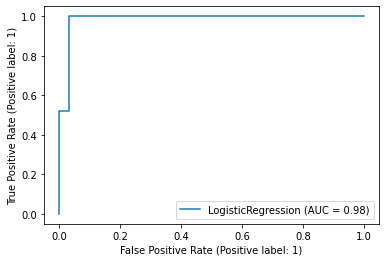

In [53]:
plot_roc_curve(model, X_test, y_test, sample_weight=None, drop_intermediate=True, response_method='auto', name=None, ax=None, pos_label=None)